In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.inspection import permutation_importance

import statsmodels.api as sm

sns.set_style("whitegrid")

In [ ]:


from google.colab import drive
drive.mount('/content/drive')

import zipfile

zip_path     = "/content/drive/MyDrive/Data.zip"
extract_path = "/content/Data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


BASE_PATH = "/content/Data/Data/Data/dataset_split"

TRAIN_CSV = f"{BASE_PATH}/train/train.csv"
VAL_CSV   = f"{BASE_PATH}/val/val.csv"
TEST_CSV  = f"{BASE_PATH}/test/test.csv"

TRAIN_IMG = f"{BASE_PATH}/train/images"
VAL_IMG   = f"{BASE_PATH}/val/images"
TEST_IMG  = f"{BASE_PATH}/test/images"

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Val shape:",   val_df.shape)
print("Test shape:",  test_df.shape)

Train shape: (13015, 34)
Val shape: (1632, 34)
Test shape: (1619, 34)


In [ ]:


print("\nColumns:", train_df.columns.tolist())
print("\nInfo:")
train_df.info()
print("\nMissing Values:\n", train_df.isna().sum())
print("\nDuplicates:", train_df.duplicated().sum())


Columns: ['image_id', 'patient_id', 'camera', 'patient_age', 'comorbidities', 'diabetes_time_y', 'insuline', 'patient_sex', 'exam_eye', 'diabetes', 'nationality', 'optic_disc', 'vessels', 'macula', 'DR_SDRG', 'DR_ICDR', 'focus', 'Illuminaton', 'image_field', 'artifacts', 'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'other', 'quality']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13015 entries, 0 to 13014
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   image_id                  13015 non-null  object 
 1   patient_id                13015 non-null  int64  
 2   camera                    13015 non-null  object 
 3   patient_age               8669 non-null   float64
 4   comorbidities             6396 non-null   object 
 5   

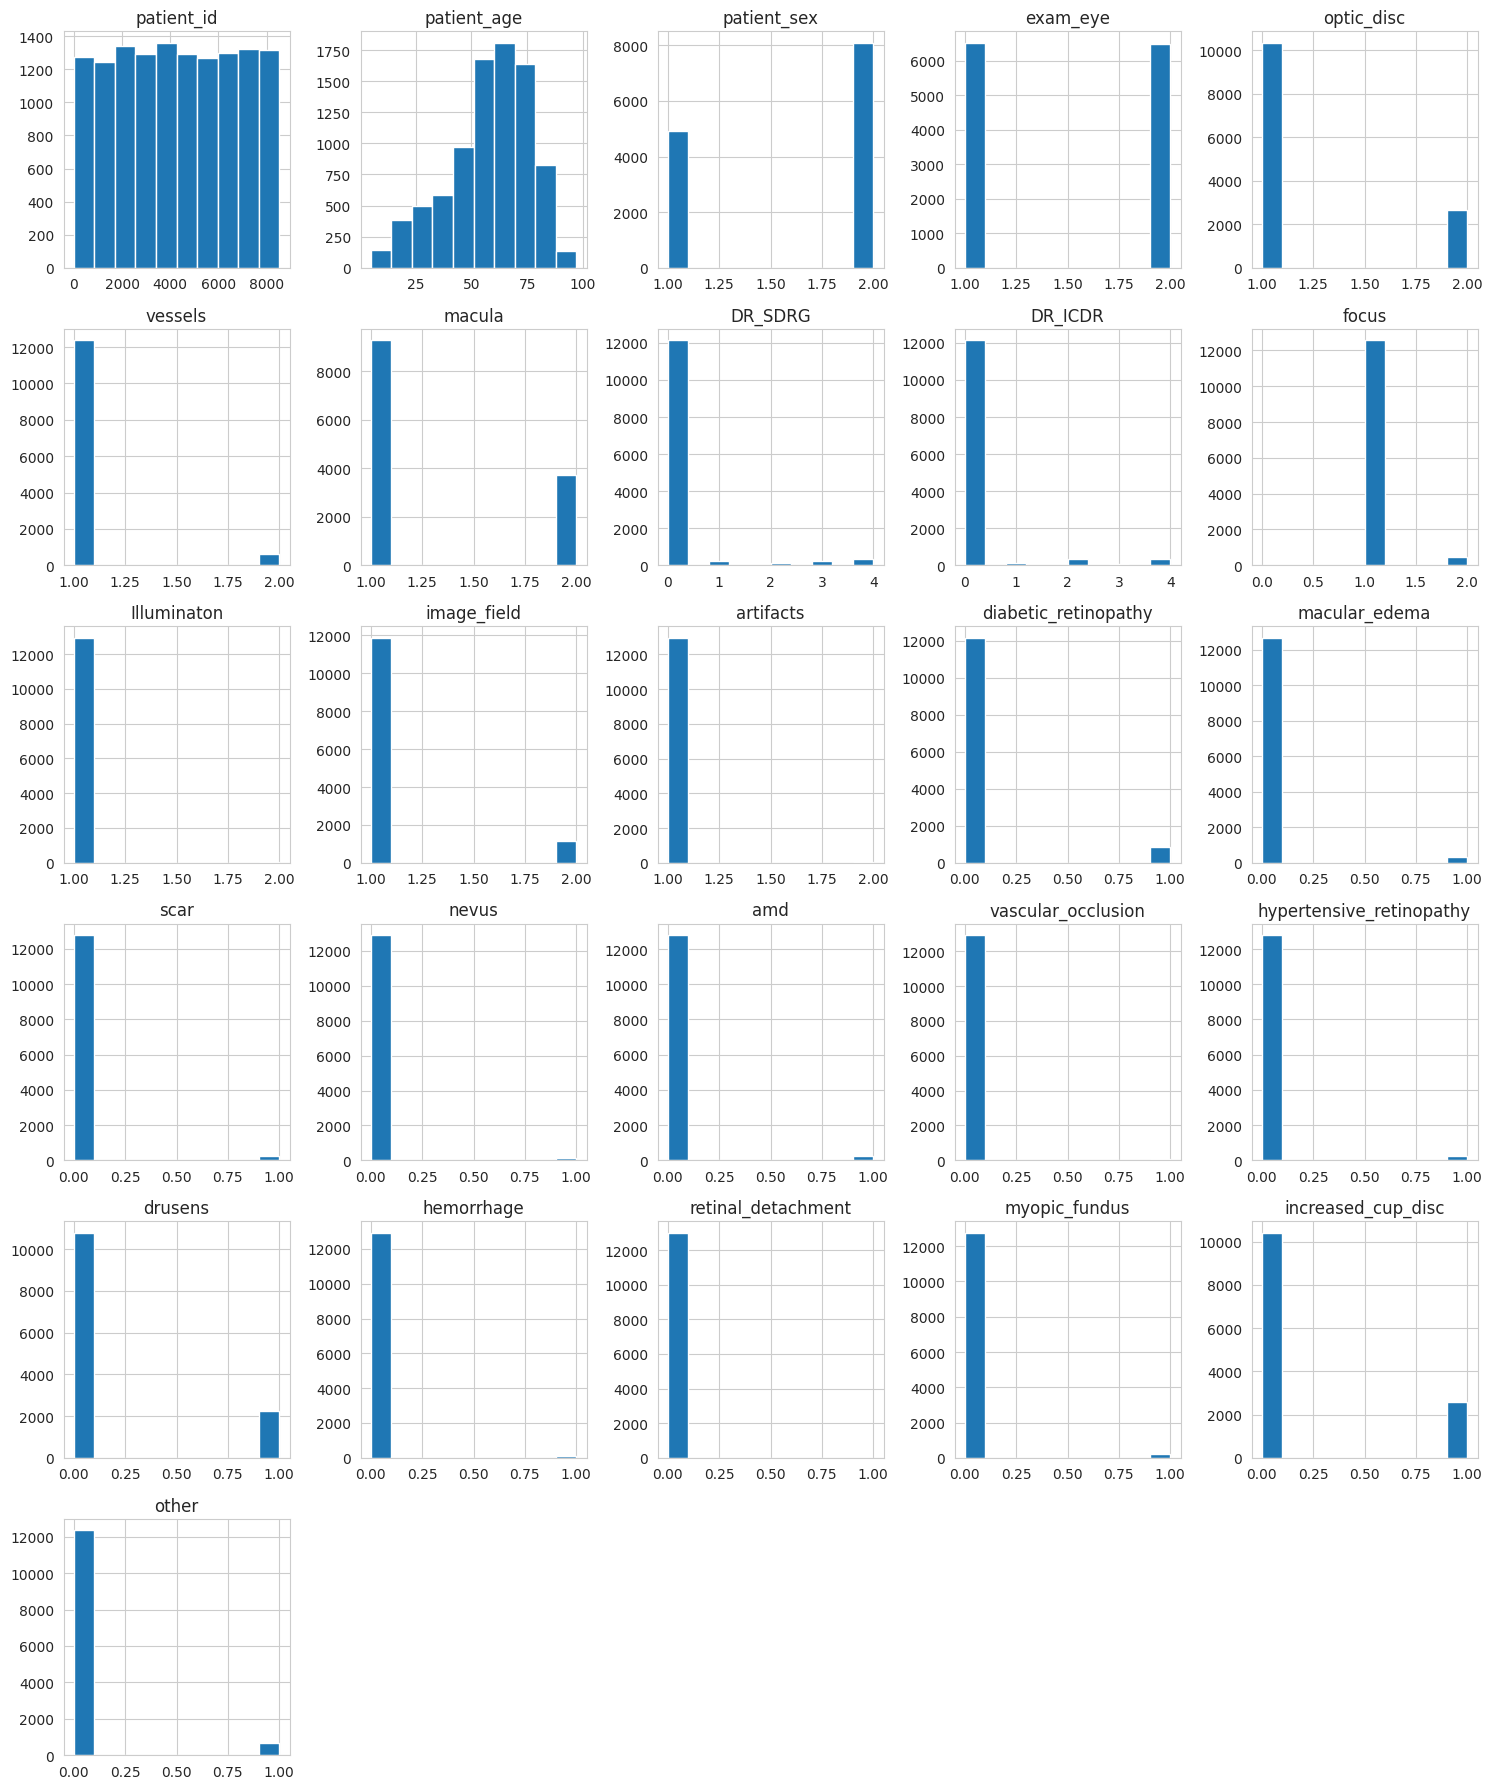

In [ ]:
train_df.hist(figsize=(15, 18))
plt.tight_layout()
plt.show()

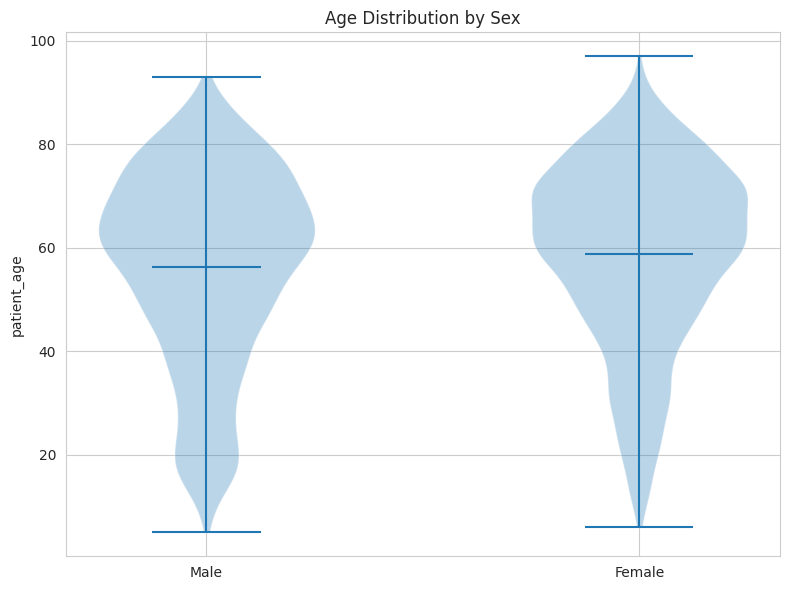

In [ ]:
# Age distribution by sex
male_age   = train_df[train_df['patient_sex'] == 1]['patient_age'].dropna()
female_age = train_df[train_df['patient_sex'] == 2]['patient_age'].dropna()

plt.figure(figsize=(8, 6))
plt.violinplot([male_age, female_age], showmeans=True)
plt.xticks([1, 2], ['Male', 'Female'])
plt.ylabel('patient_age')
plt.title('Age Distribution by Sex')
plt.tight_layout()
plt.show()

DR_ICDR
0    12151
1      124
2      357
3       66
4      317
Name: count, dtype: int64

Normalized:
 DR_ICDR
0    0.933615
1    0.009527
2    0.027430
3    0.005071
4    0.024357
Name: proportion, dtype: float64


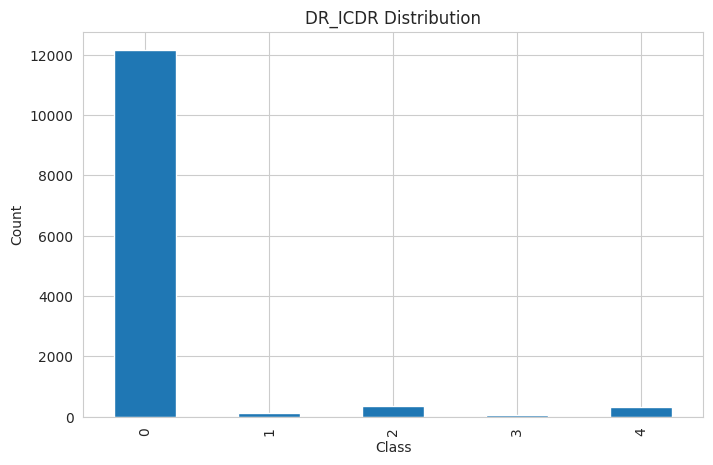

In [ ]:


# Target distribution
print(train_df["DR_ICDR"].value_counts().sort_index())
print("\nNormalized:\n", train_df["DR_ICDR"].value_counts(normalize=True).sort_index())

plt.figure(figsize=(8, 5))
train_df["DR_ICDR"].value_counts().sort_index().plot(kind="bar")
plt.title("DR_ICDR Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:


print("Macular Edema:\n",         train_df["macular_edema"].value_counts(dropna=False))
print("\nDiabetic Retinopathy:\n", train_df["diabetic_retinopathy"].value_counts(dropna=False))

print("Unique patients in train:", train_df["patient_id"].nunique())
print("Unique patients in val:",   val_df["patient_id"].nunique())
print("Unique patients in test:",  test_df["patient_id"].nunique())

print("\nImages per patient distribution:")
print(train_df.groupby("patient_id")["exam_eye"].count().value_counts())

Macular Edema:
 macular_edema
0    12694
1      321
Name: count, dtype: int64

Diabetic Retinopathy:
 diabetic_retinopathy
0    12159
1      856
Name: count, dtype: int64
Unique patients in train: 6819
Unique patients in val: 852
Unique patients in test: 853

Images per patient distribution:
exam_eye
2    6165
1     642
4       7
3       5
Name: count, dtype: int64


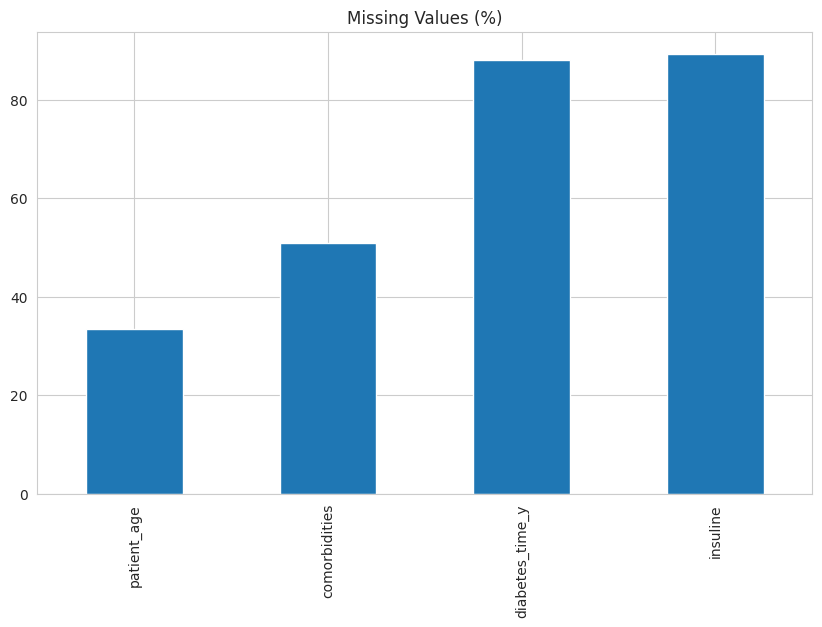

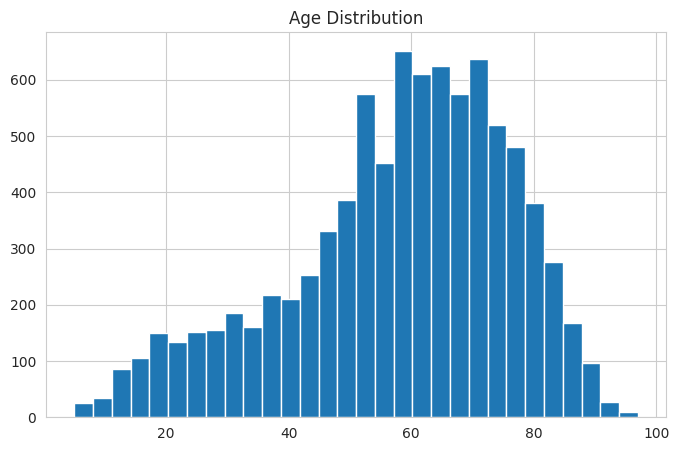

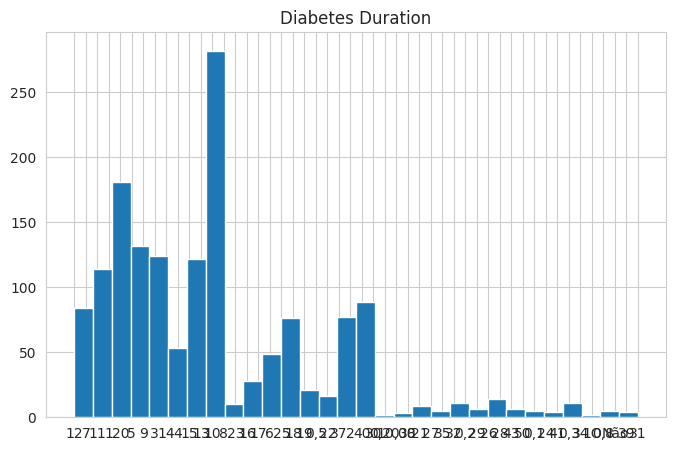

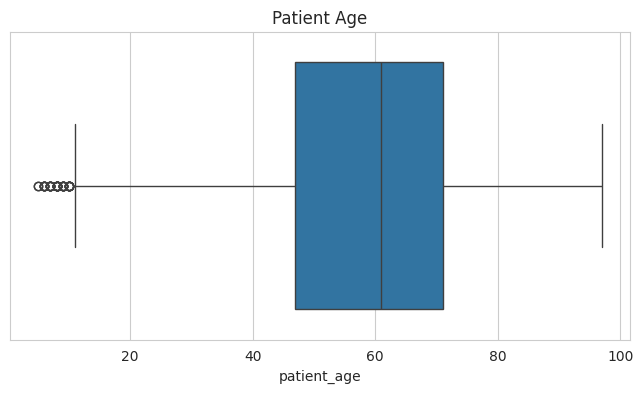

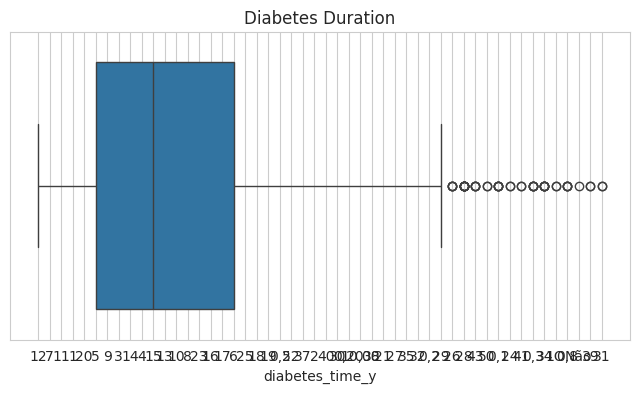

In [ ]:


# Missing values bar chart
missing_percent = train_df.isnull().mean() * 100
plt.figure(figsize=(10, 6))
missing_percent[missing_percent > 0].sort_values().plot(kind='bar')
plt.title("Missing Values (%)")
plt.show()

plt.figure(figsize=(8, 5))
train_df["patient_age"].hist(bins=30)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(8, 5))
train_df["diabetes_time_y"].hist(bins=30)
plt.title("Diabetes Duration")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=train_df["patient_age"])
plt.title("Patient Age")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=train_df["diabetes_time_y"])
plt.title("Diabetes Duration")
plt.show()

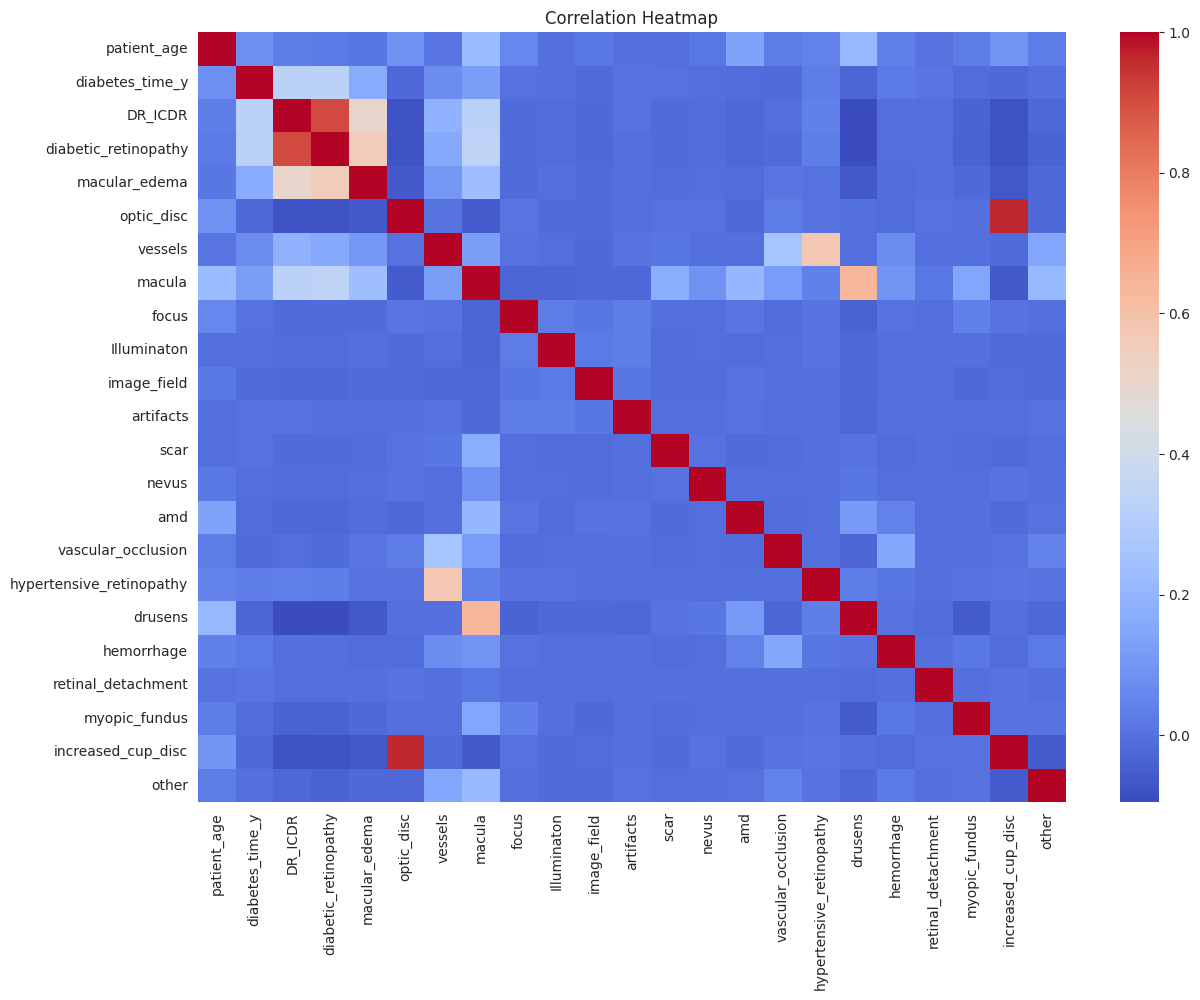

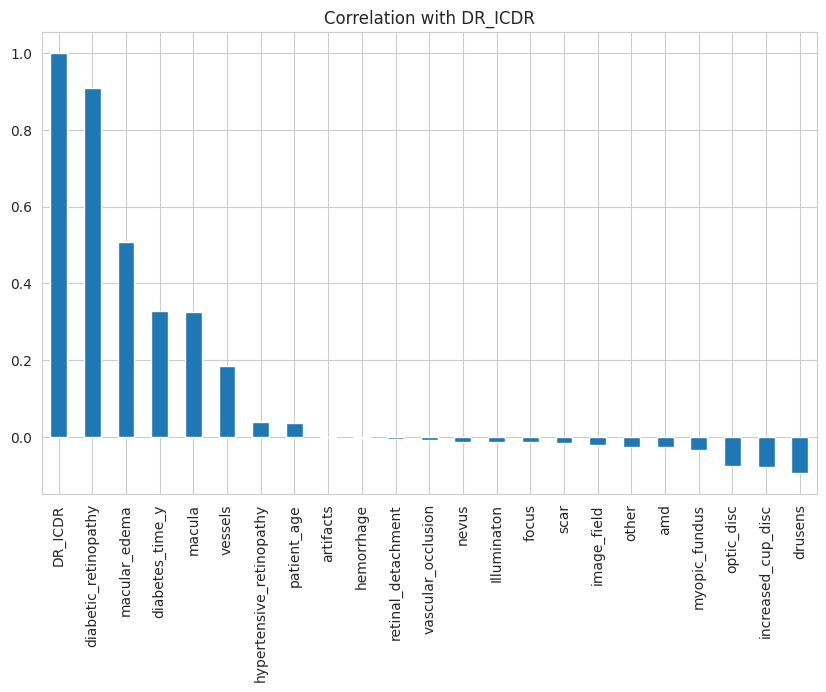

In [ ]:


numeric_cols = [
    "patient_age", "diabetes_time_y", "DR_ICDR",
    "diabetic_retinopathy", "macular_edema", "optic_disc",
    "vessels", "macula", "focus", "Illuminaton", "image_field",
    "artifacts", "scar", "nevus", "amd", "vascular_occlusion",
    "hypertensive_retinopathy", "drusens", "hemorrhage",
    "retinal_detachment", "myopic_fundus", "increased_cup_disc", "other"
]

# Apply comma→dot fix and numeric conversion on ALL splits
for df in [train_df, val_df, test_df]:
    for col in numeric_cols:
        if col not in df.columns:
            continue
        df[col] = df[col].astype(str).str.replace(",", ".", regex=False)
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill NaNs with TRAIN medians (avoid data leakage)
train_medians = train_df[numeric_cols].median()
for df in [train_df, val_df, test_df]:
    existing = [c for c in numeric_cols if c in df.columns]
    df[existing] = df[existing].fillna(train_medians[existing])

# Correlation heatmap
valid_num_cols = [c for c in numeric_cols if c in train_df.columns]
plt.figure(figsize=(14, 10))
sns.heatmap(train_df[valid_num_cols].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

corr_target = train_df[valid_num_cols].corr()["DR_ICDR"].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
corr_target.plot(kind='bar')
plt.title("Correlation with DR_ICDR")
plt.show()

In [ ]:


for col in ["patient_age", "diabetes_time_y"]:
    q1, q3  = train_df[col].quantile([0.25, 0.75])
    iqr      = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    for df in [train_df, val_df, test_df]:
        df[col] = np.clip(df[col], lower, upper)

for df in [train_df, val_df, test_df]:
    df["insuline"]      = df["insuline"].fillna("unknown")
    df["comorbidities"] = df["comorbidities"].fillna("unknown")

image_path
True    13015
Name: count, dtype: int64
image_path
True    1632
Name: count, dtype: int64
image_path
True    1619
Name: count, dtype: int64


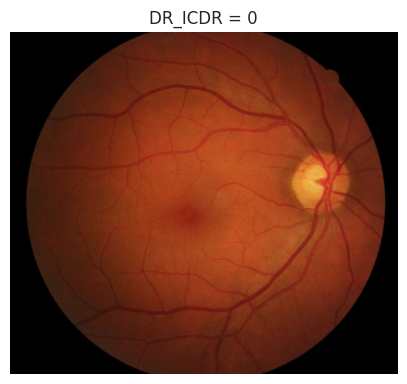

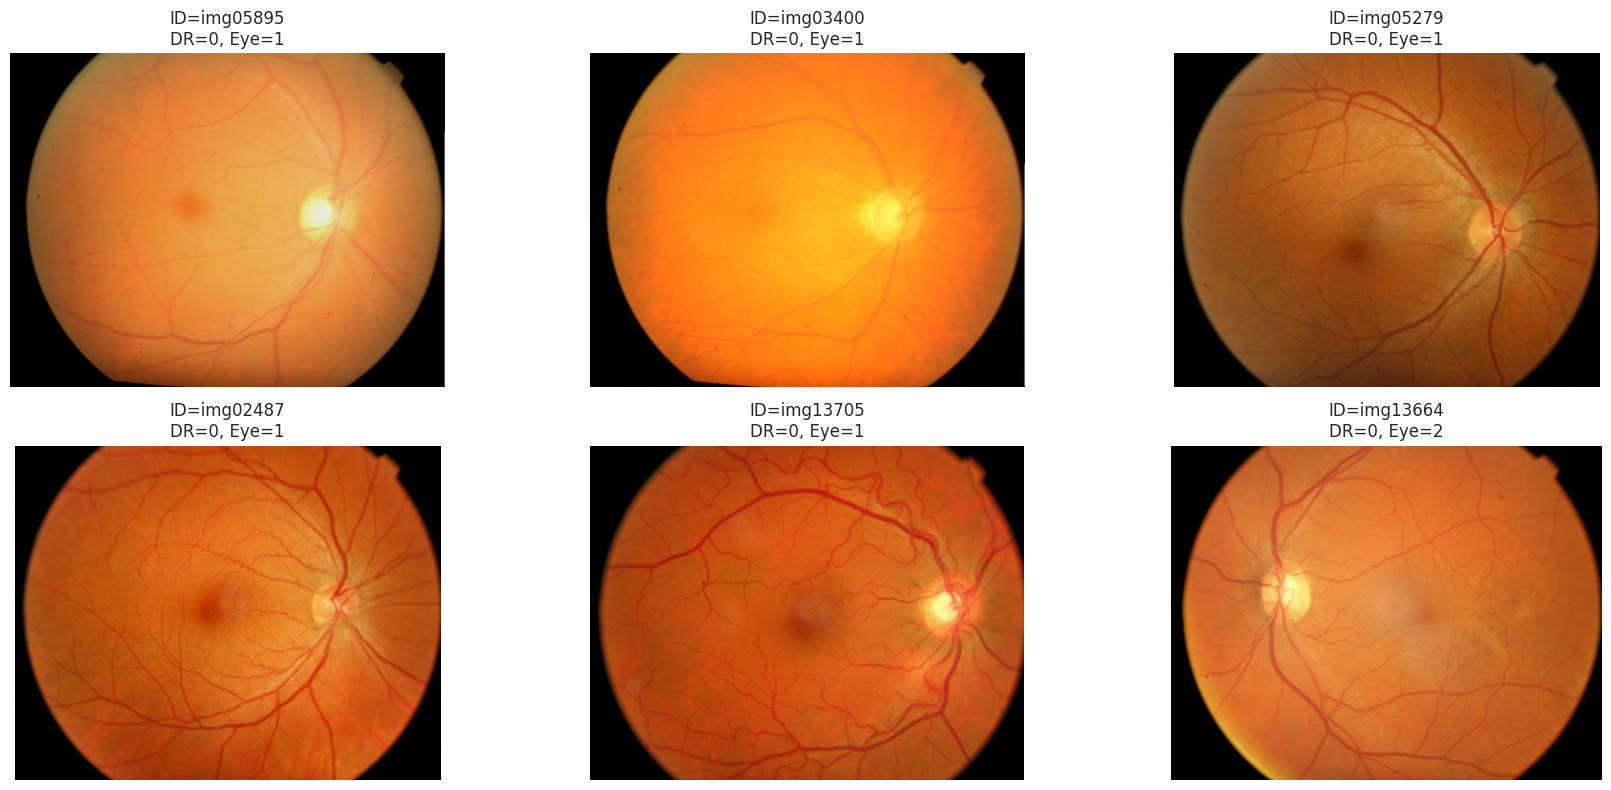

In [ ]:


train_df["image_path"] = train_df["image_id"].apply(lambda x: os.path.join(TRAIN_IMG, f"{x}.jpg"))
val_df["image_path"]   = val_df["image_id"].apply(lambda x: os.path.join(VAL_IMG,   f"{x}.jpg"))
test_df["image_path"]  = test_df["image_id"].apply(lambda x: os.path.join(TEST_IMG,  f"{x}.jpg"))

print(train_df["image_path"].apply(os.path.exists).value_counts())
print(val_df["image_path"].apply(os.path.exists).value_counts())
print(test_df["image_path"].apply(os.path.exists).value_counts())

sample_path = train_df.iloc[0]["image_path"]
sample_img  = Image.open(sample_path)

plt.figure(figsize=(5, 5))
plt.imshow(sample_img)
plt.axis("off")
plt.title(f'DR_ICDR = {train_df.iloc[0]["DR_ICDR"]}')
plt.show()

def show_samples(df, n=6):
    samples = df.sample(n, random_state=42)
    plt.figure(figsize=(18, 8))
    for i, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row["image_path"])
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(f'ID={row["image_id"]}\nDR={row["DR_ICDR"]}, Eye={row["exam_eye"]}')
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_df, n=6)

In [ ]:


categorical_cols = [
    "camera", "comorbidities", "insuline",
    "patient_sex", "exam_eye", "diabetes",
    "nationality", "quality"
]
categorical_cols = [c for c in categorical_cols if c in train_df.columns]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))

    mapping = {cls: idx for idx, cls in enumerate(le.classes_)}
    for df in [val_df, test_df]:
        df[col] = df[col].astype(str).map(lambda x, m=mapping: m.get(x, 0))

    encoders[col] = le

In [ ]:


drop_cols  = ["image_id", "image_path", "patient_id"]
target_col = "DR_ICDR"

feature_cols = [
    col for col in train_df.columns
    if col not in drop_cols + [target_col]
    and train_df[col].dtype != object
]

print("Feature columns:", feature_cols)

Feature columns: ['camera', 'patient_age', 'comorbidities', 'diabetes_time_y', 'insuline', 'patient_sex', 'exam_eye', 'diabetes', 'nationality', 'optic_disc', 'vessels', 'macula', 'DR_SDRG', 'focus', 'Illuminaton', 'image_field', 'artifacts', 'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'other', 'quality']


In [ ]:


# Build initial X/y from train for feature selection
X = train_df[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
y = train_df[target_col]

#---------------------------------- FEATURE SELECTION


from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, chi2, f_classif
from sklearn.preprocessing import MinMaxScaler

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

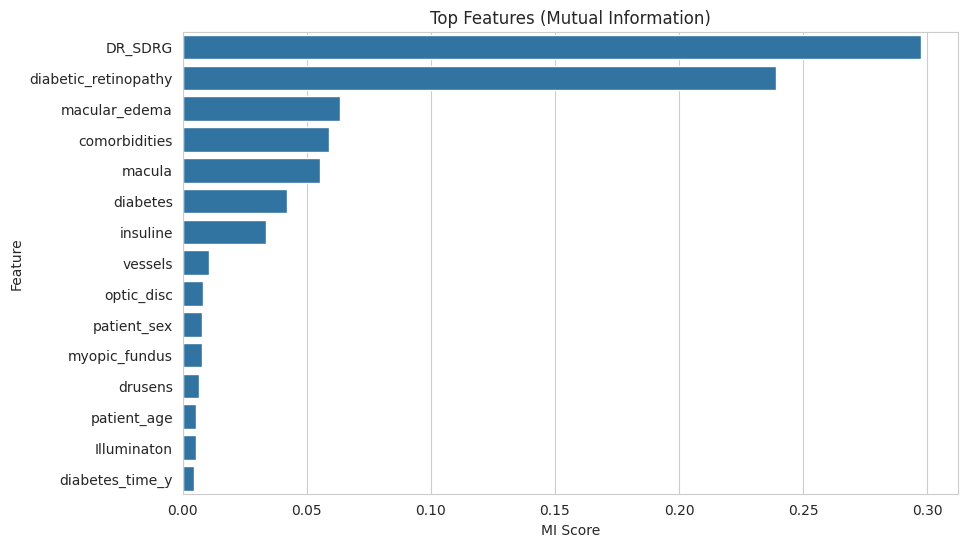

In [ ]:
# Mutual Information
mi_scores = mutual_info_classif(X_tr, y_tr)
mi_df = pd.DataFrame({"Feature": feature_cols, "MI Score": mi_scores}).sort_values("MI Score", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=mi_df.head(15), x="MI Score", y="Feature")
plt.title("Top Features (Mutual Information)")
plt.show()

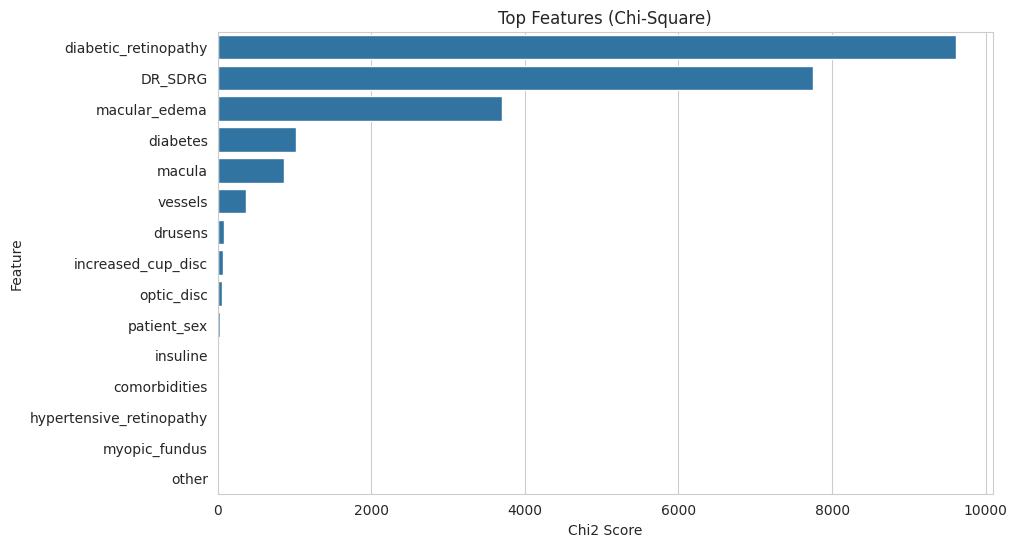

In [ ]:


# Chi-Square
scaler_chi    = MinMaxScaler()
X_tr_nonneg   = scaler_chi.fit_transform(X_tr)
chi_scores, _ = chi2(X_tr_nonneg, y_tr)
chi_df = pd.DataFrame({"Feature": feature_cols, "Chi2 Score": chi_scores}).sort_values("Chi2 Score", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=chi_df.head(15), x="Chi2 Score", y="Feature")
plt.title("Top Features (Chi-Square)")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [3 8] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


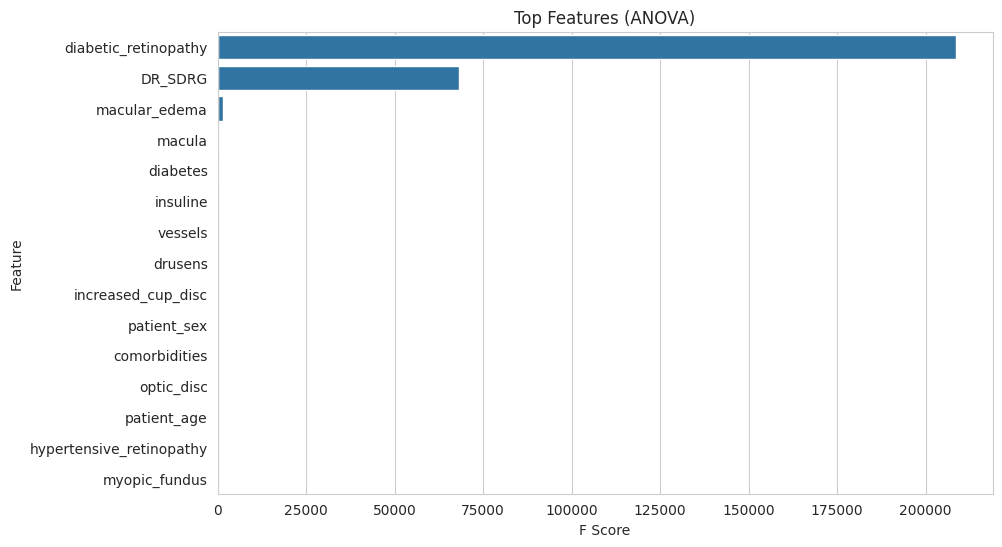

In [ ]:


# ANOVA F-score
f_scores, _ = f_classif(X_tr, y_tr)
f_df = pd.DataFrame({"Feature": feature_cols, "F Score": f_scores}).sort_values("F Score", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=f_df.head(15), x="F Score", y="Feature")
plt.title("Top Features (ANOVA)")
plt.show()

In [ ]:


# Union of top features
selected_features = list(
    set(mi_df.head(15)["Feature"]) |
    set(chi_df.head(15)["Feature"]) |
    set(f_df.head(15)["Feature"])
)
selected_features = [f for f in selected_features if train_df[f].dtype != object]

for df in [train_df, val_df, test_df]:
    df[selected_features] = df[selected_features].apply(pd.to_numeric, errors='coerce').fillna(0)

X_train = train_df[selected_features].copy()
y_train = train_df[target_col].copy()

X_val = val_df[selected_features].copy()
y_val = val_df[target_col].copy()

X_test = test_df[selected_features].copy()
y_test = test_df[target_col].copy()

In [ ]:


--------------------------------------# LEARNING CURVES

from sklearn.model_selection import learning_curve, validation_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Decision Tree — overfitting demo
dt = DecisionTreeClassifier(max_depth=None, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    dt, X_train, y_train, cv=5, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

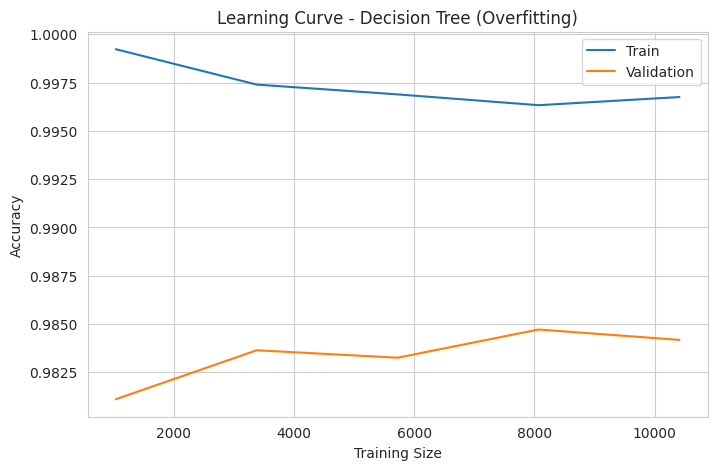

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1),   label="Validation")
plt.title("Learning Curve - Decision Tree (Overfitting)")
plt.xlabel("Training Size"); plt.ylabel("Accuracy"); plt.legend(); plt.show()

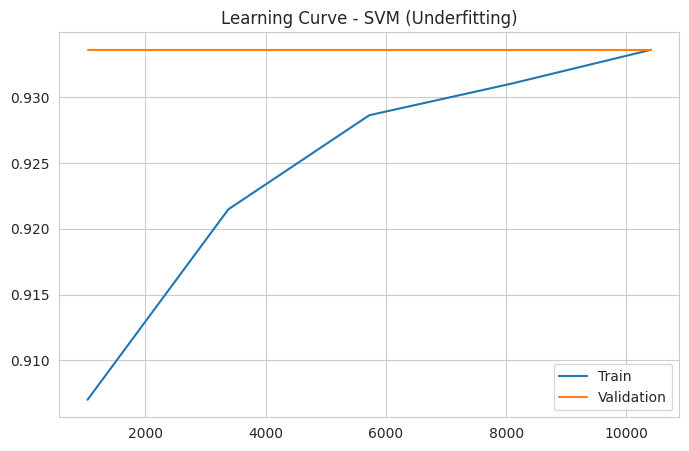

In [ ]:


# SVM — underfitting demo
svm = SVC(C=0.0001)
train_sizes, train_scores, val_scores = learning_curve(
    svm, X_train, y_train, cv=5, scoring="accuracy"
)
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1),   label="Validation")
plt.title("Learning Curve - SVM (Underfitting)"); plt.legend(); plt.show()

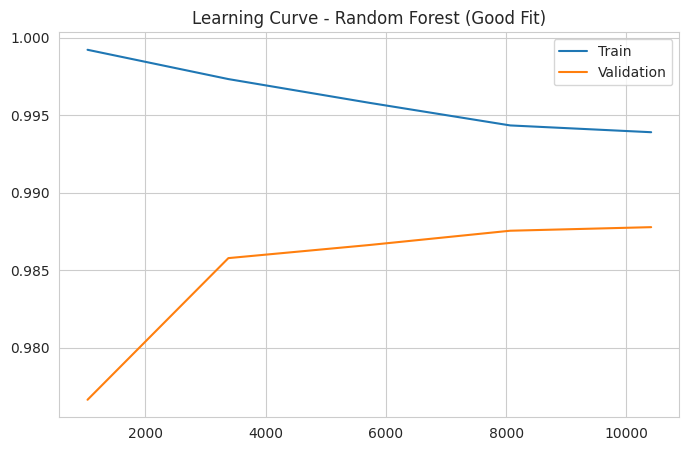

In [ ]:


# Random Forest — good fit demo
rf_temp = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    rf_temp, X_train, y_train, cv=5, scoring="accuracy"
)
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1),   label="Validation")
plt.title("Learning Curve - Random Forest (Good Fit)"); plt.legend(); plt.show()

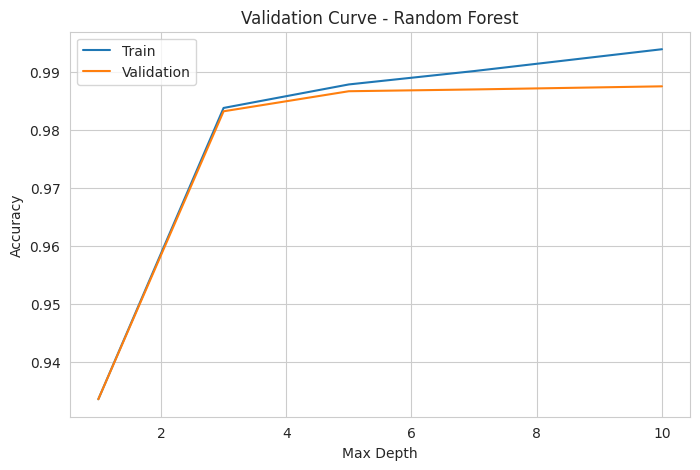

In [ ]:
# Validation curve — max_depth
param_range = [1, 3, 5, 7, 10]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=42), X_train, y_train,
    param_name="max_depth", param_range=param_range, cv=5, scoring="accuracy"
)
plt.figure(figsize=(8, 5))
plt.plot(param_range, train_scores.mean(axis=1), label="Train")
plt.plot(param_range, val_scores.mean(axis=1),   label="Validation")
plt.title("Validation Curve - Random Forest")
plt.xlabel("Max Depth"); plt.ylabel("Accuracy"); plt.legend(); plt.show()

In [ ]:
# VARIANCE THRESHOLD + CORRELATION FILTER

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)
selected_features_var = X_train.columns[selector.get_support()]
print("Features kept after variance threshold:", len(selected_features_var))

Features kept after variance threshold: 16


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


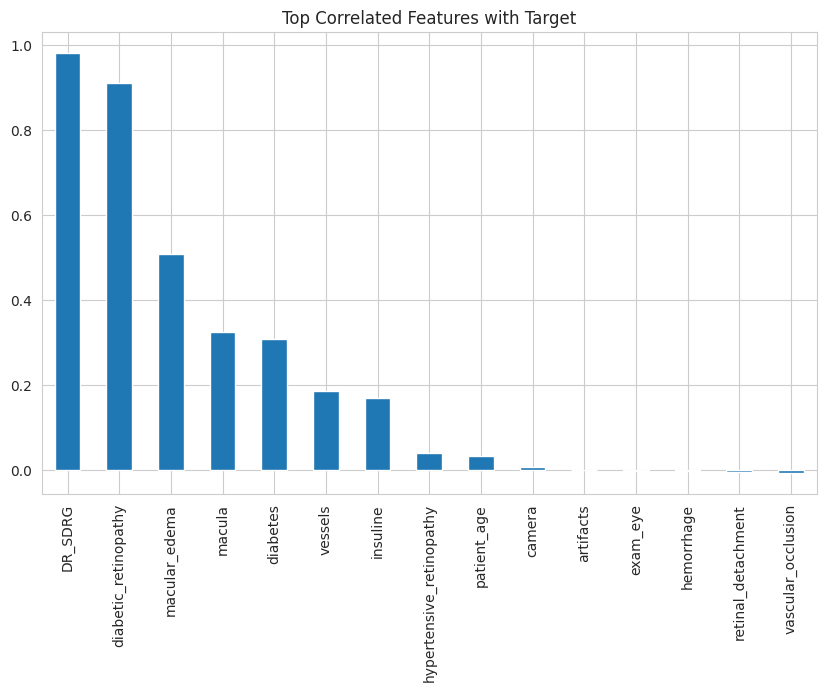

In [ ]:


corr_target = train_df[feature_cols].corrwith(train_df[target_col]).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
corr_target.head(15).plot(kind='bar')
plt.title("Top Correlated Features with Target")
plt.show()

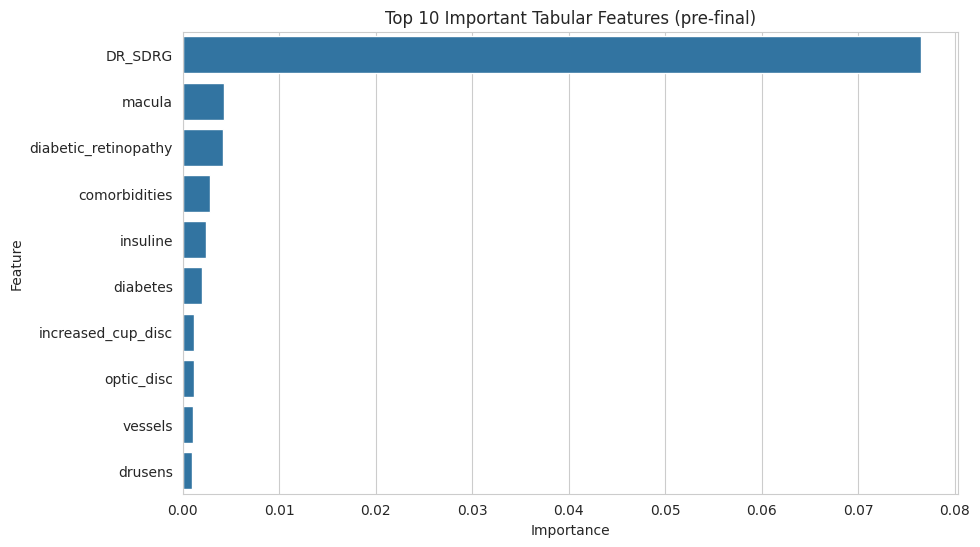

In [ ]:


# PERMUTATION IMPORTANCE

rf_explain = RandomForestClassifier(random_state=42)
rf_explain.fit(X_train, y_train)

perm_pre = permutation_importance(rf_explain, X_val, y_val, n_repeats=10, random_state=42)

importance_df = pd.DataFrame({
    "Feature":    selected_features,
    "Importance": perm_pre.importances_mean
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
plt.title("Top 10 Important Tabular Features (pre-final)")
plt.show()